# Exsersise 2-1


In [2]:
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib','inline')
import cv2

In [4]:
img = cv2.imread('../images/rainbow.jpg')

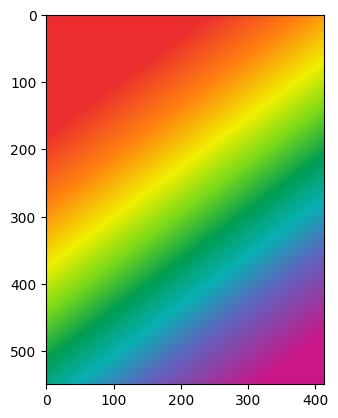

In [5]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

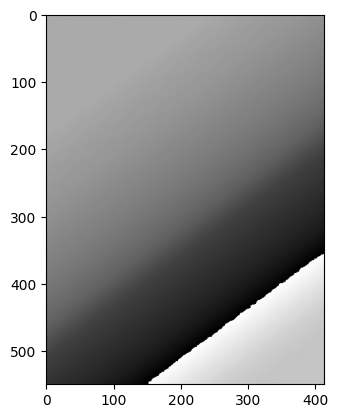

In [6]:
img1 = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)
plt.imshow(img1[:,:,0], cmap='gray')


In [7]:
imgA = cv2.imread('../images/dog_backpack.jpg')
imgA = cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB)
imgB = cv2.imread('../images/watermark_no_copy.png')
imgB = cv2.cvtColor(imgB, cv2.COLOR_BGR2RGB)


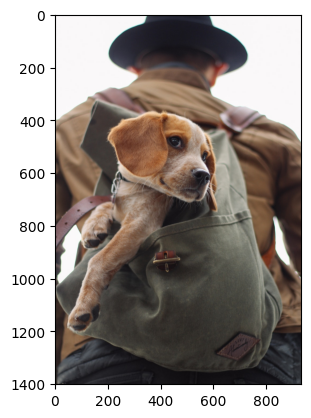

In [9]:
plt.imshow(imgA)

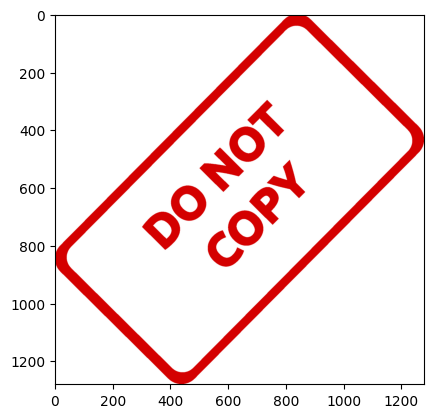

In [10]:
plt.imshow(imgB)

In [11]:
imgB.shape

(1280, 1277, 3)

ImgA shape ImgB shape таарахгүй байсан учир ажиллахгүй байсан.

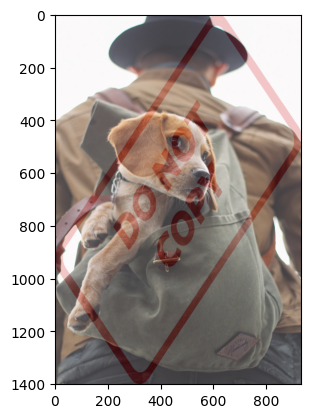

In [14]:
# Resize imgB to match imgA's shape
imgB_resized = cv2.resize(imgB, (imgA.shape[1], imgA.shape[0]))
blended_img = cv2.addWeighted(src1=imgA, alpha=0.8, src2=imgB_resized, beta=0.2, gamma=0)
plt.imshow(blended_img)

In [16]:
imgA = cv2.imread('../images/dog_backpack.jpg')
imgA = cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB)
imgB = cv2.imread('../images/watermark_no_copy.png')
imgB = cv2.cvtColor(imgB, cv2.COLOR_BGR2RGB)


In [17]:
imgB = cv2.resize(imgB, (500, 500))

In [18]:
img_large = imgA
img_small = imgB

In [20]:
x_offset = 200
y_offset = 200
img_small.shape[0]

500

In [23]:
img_large_reg = img_large[y_offset:y_offset+img_small.shape[0], x_offset:x_offset+img_small.shape[1]]*0.7;
img_small_blend = img_small*0.3

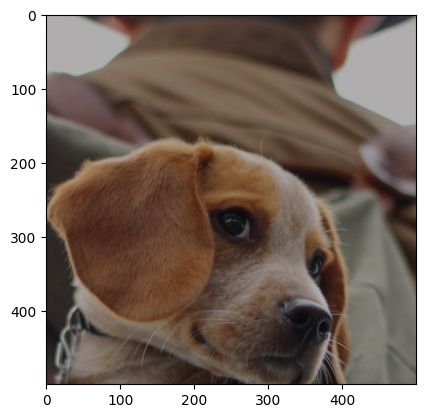

In [24]:
img_large_reg = img_large_reg.astype(int)
img_small_blend = img_small_blend.astype(int)
plt.imshow(img_large_reg)


In [25]:
img_large[y_offset:y_offset+img_small.shape[0], x_offset:y_offset+img_small.shape[1]] = img_large_reg + img_small_blend

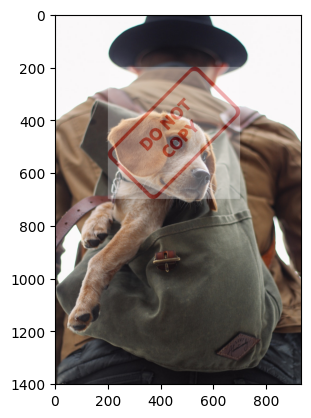

In [26]:
plt.imshow(img_large)

In [28]:
import numpy as np
import cv2
imgA = cv2.imread('../images/dog_backpack.jpg')
imgA = cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB)
imgB = cv2.imread('../images/watermark_no_copy.png')
imgB = cv2.cvtColor(imgB, cv2.COLOR_BGR2RGB)
imgB=cv2.resize(imgB,(500,500))
x_offset = 200
y_offset = 200
img_large = imgA
img_small = imgB
#Region of interest ROI
img_large_reg = img_large[y_offset:y_offset+img_small.shape[0], x_offset:y_offset+img_small.shape[1]];
imgBgray = imgB = cv2.cvtColor(imgB, cv2.COLOR_BGR2GRAY)
imgBgray.shape

(500, 500)

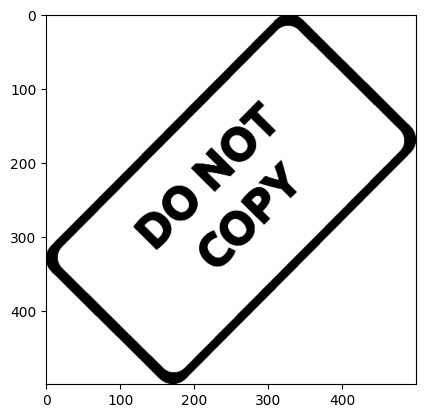

In [29]:
plt.imshow(imgBgray, cmap='gray')


(500, 500)

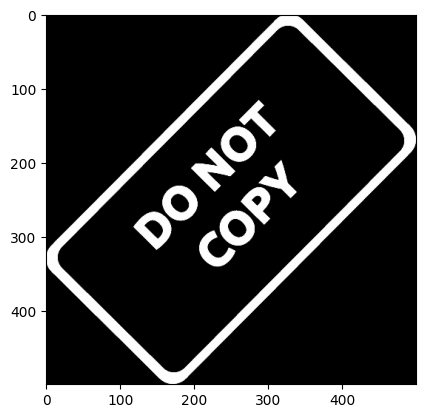

In [30]:
mask_inv = cv2.bitwise_not(imgBgray)
plt.imshow(mask_inv, cmap='gray')
mask_inv.shape

In [31]:
white_back = np.full(imgB.shape, 255, dtype=np.uint8)

In [32]:
bk = cv2.bitwise_and(white_back, white_back, mask=mask_inv)

In [33]:
bk.shape
bk2 = np.full((imgB.shape[0],imgB.shape[1],3), 255, dtype=np.uint8)
bk2[:,:,0] = bk;
bk2[:,:,1] = bk;
bk2[:,:,2] = bk;


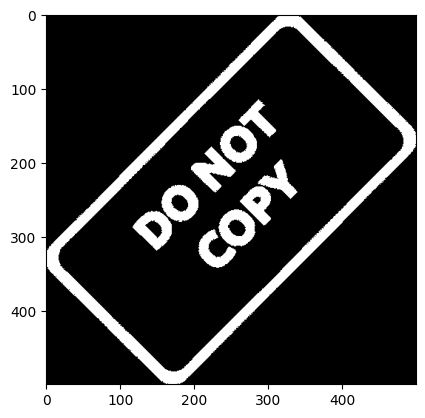

In [34]:
plt.imshow(bk, cmap='gray')

In [35]:
img_large_reg[:,:,0].shape
bk.shape

(500, 500)

In [36]:
fg = cv2.bitwise_or(img_large_reg, bk2)
fg.shape

(500, 500, 3)

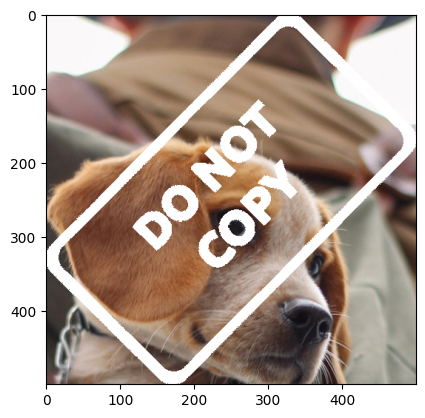

In [37]:
plt.imshow(fg, cmap='gray')

In [38]:
img_large[y_offset:y_offset+img_small.shape[0], x_offset:y_offset+img_small.shape[1]] = fg


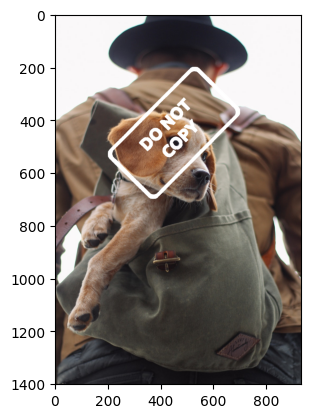

In [39]:
plt.imshow(img_large)

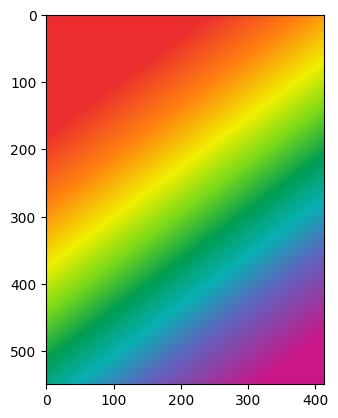

In [40]:
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib','inline')
import cv2
img = cv2.imread('../images/rainbow.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

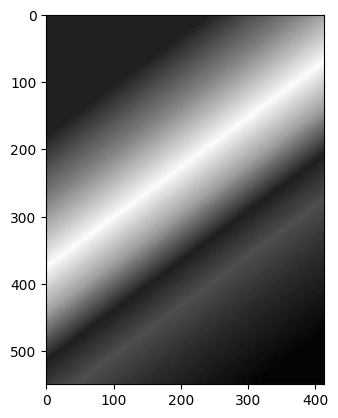

In [41]:
img_gray = cv2.imread('../images/rainbow.jpg',0)
plt.imshow(img_gray, cmap='gray')


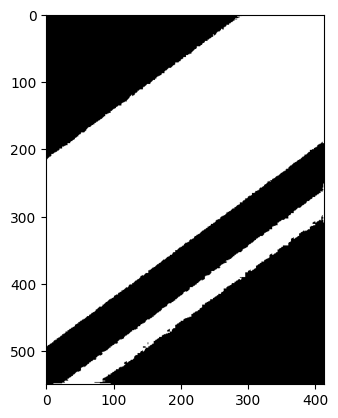

In [42]:
ret, thresh1 = cv2.threshold(img_gray, 120, 255, cv2.THRESH_BINARY)
plt.imshow(thresh1, cmap='gray')


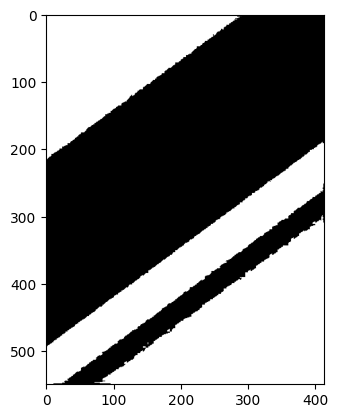

In [43]:
ret, thresh2 = cv2.threshold(img_gray, 120, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh2, cmap='gray')

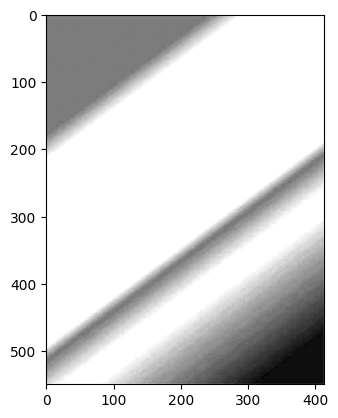

In [44]:
ret, thresh3 = cv2.threshold(img_gray, 120, 255, cv2.THRESH_TRUNC)
plt.imshow(thresh3, cmap='gray')


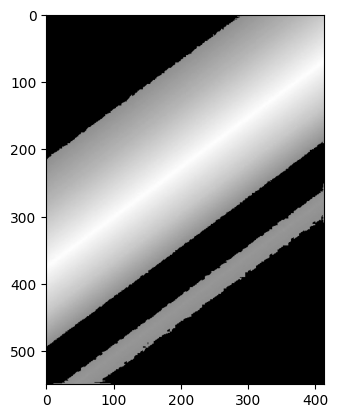

In [45]:
ret, thresh4 = cv2.threshold(img_gray, 120, 255, cv2.THRESH_TOZERO)
plt.imshow(thresh4, cmap='gray')

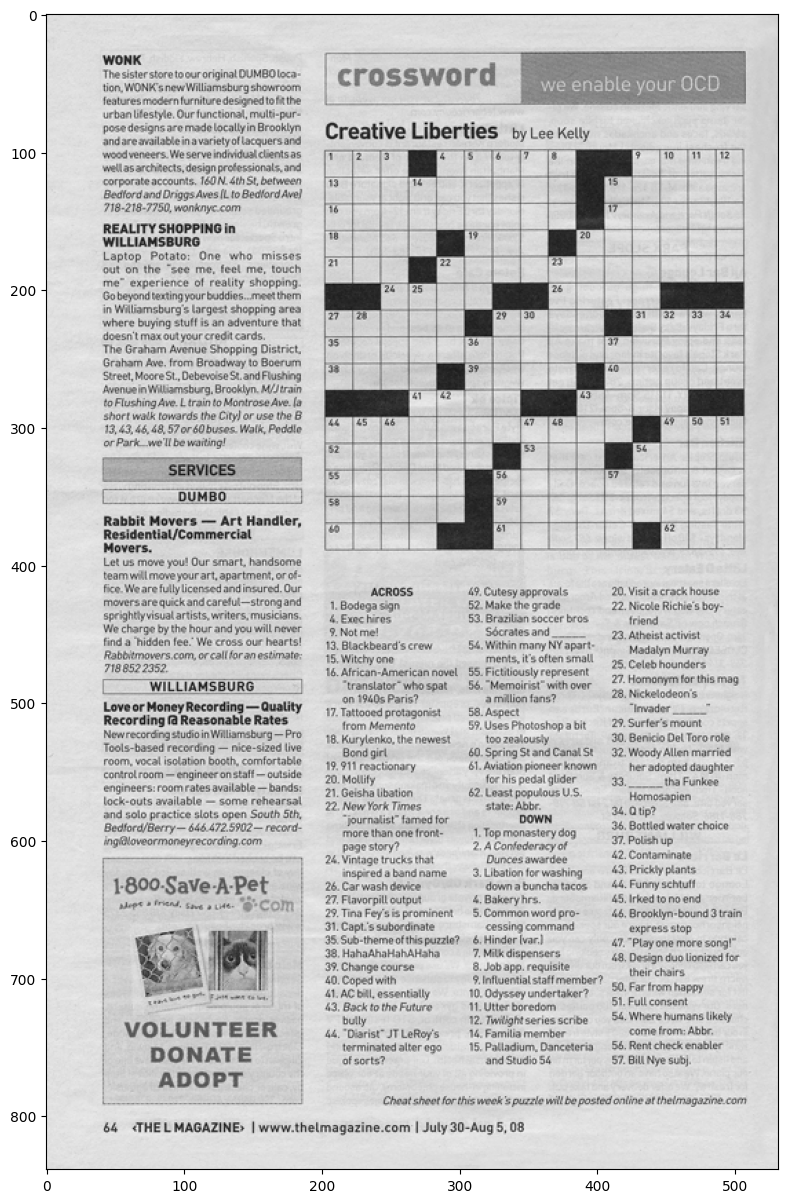

In [47]:
img2 = cv2.imread('../images/crossword.jpg',0)
def show_img(image, plt_size):
    fig = plt.figure(figsize=(plt_size,plt_size))
    ax = fig.add_subplot(111)
    ax.imshow(image,cmap='gray')
show_img(img2, 15)

True

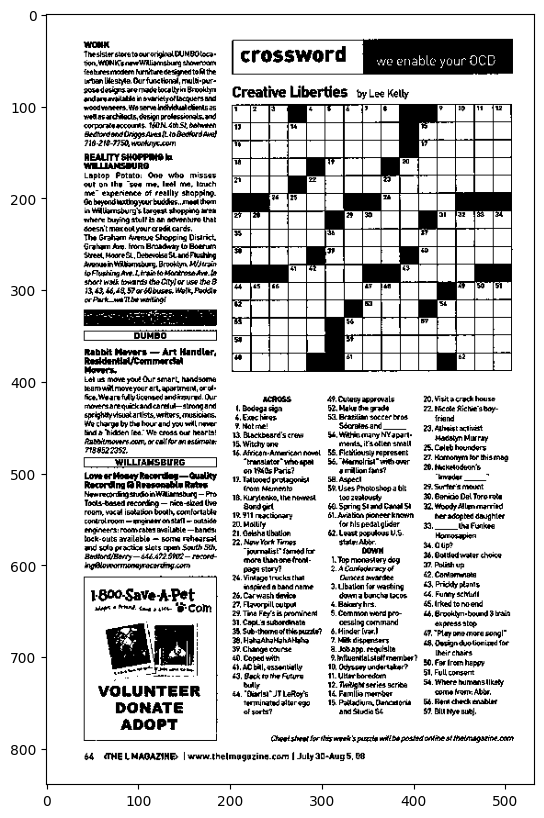

In [48]:
ter, th1 = cv2.threshold(img2, 180, 255, cv2.THRESH_BINARY)
show_img(th1, 10)
cv2.imwrite('../images/crossword_binary.jpg', th1)

True

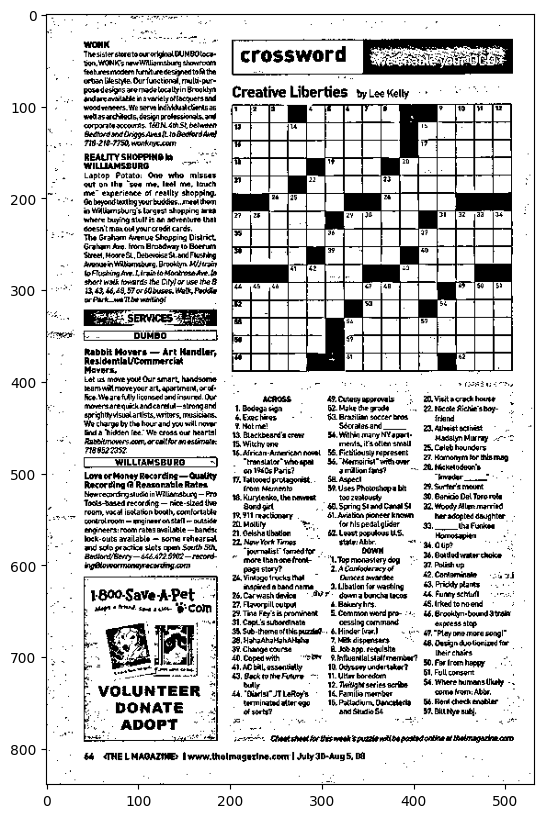

In [50]:
th2 = cv2.adaptiveThreshold(img2, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 25,8)
show_img(th2, 10)
cv2.imwrite('../images/th2.jpg',th2)

True

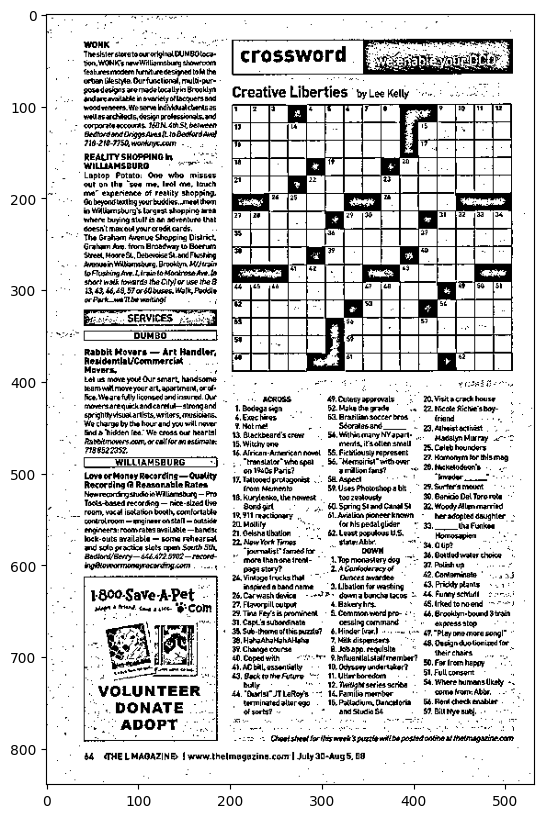

In [51]:
th3 = cv2.adaptiveThreshold(img2, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,25, 8 )
show_img(th3, 10)
cv2.imwrite('../images/th3.jpg',th3)